In [28]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [29]:
load_data = r"G:\My Drive\New_Working_Files\KNIME\CTU_2026\ML\MMM_Model.xlsx"
try:
    df=pd.read_excel(load_data)
    print("File loaded Successfully!")
except:
    print("Error in uploading")
    raise

df=df.fillna(0)

File loaded Successfully!



Simple MMM Results
Model Accuracy (R-Squared): 0.67
------------------------------
promo_discount_spend: For every $1 Spent, you earned $5.87 in revenue
general_discount_spend: For every $1 Spent, you earned $1.44 in revenue
bank_offer_spend: For every $1 Spent, you earned $0.00 in revenue
freebie_discount: For every $1 Spent, you earned $0.00 in revenue


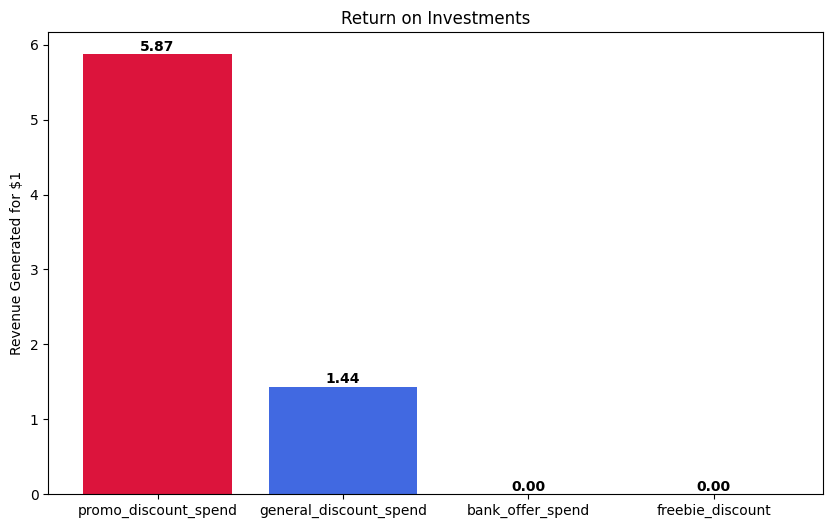

/n====================  Model Constants ++++++++++++++++++++
                            OLS Regression Results                            
Dep. Variable:          total_revenue   R-squared:                       0.669
Model:                            OLS   Adj. R-squared:                  0.669
Method:                 Least Squares   F-statistic:                     5124.
Date:                Wed, 25 Mar 2026   Prob (F-statistic):               0.00
Time:                        09:34:20   Log-Likelihood:            -1.0078e+05
No. Observations:                5063   AIC:                         2.016e+05
Df Residuals:                    5060   BIC:                         2.016e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------

C:\Users\rajeshkumar.t\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


In [30]:
def simple_adstock(spend, decay=0.5):
    adstocked_spend = np.zeros(len(spend))
    for t in range(len(spend)):
        if t==0:
            adstocked_spend[t] = spend[t]
        else:
            adstocked_spend[t] = spend[t] + decay * adstocked_spend[t-1]
    return adstocked_spend

target_col = ['total_revenue']
media_cols = ['promo_discount_spend', 'general_discount_spend', 'bank_offer_spend', 'freebie_discount']

X = pd.DataFrame()
for col in media_cols:
    X[col] = simple_adstock(df[col])

y = df[target_col]

model = LinearRegression()
model.fit(X, y)

coefficients = model.coef_.flatten()
r_sq = model.score(X, y)

print("\n" +"="*30)
print("Simple MMM Results")
print("="*30)
print(f"Model Accuracy (R-Squared): {r_sq:.2f}")
print("-" *30)

for col, coef in zip(media_cols, coefficients):
    print(f"{col}: For every $1 Spent, you earned ${coef:.2f} in revenue")

my_colors = ['crimson', 'royalblue', 'forestgreen', 'gold']
plt.figure(figsize=(10,6))
plt.bar(media_cols, coefficients, color=my_colors)
plt.title("Return on Investments")
plt.ylabel("Revenue Generated for $1")
for i, v in enumerate(coefficients):
    plt.text(i, v +0.05 , f"{v:.2f}", ha= 'center', fontweight= 'bold')
plt.show()

X_with_const = sm.add_constant(X)
model_stats = sm.OLS(df['total_revenue'], X_with_const).fit()

print("/n" + "=" * 20 + "  Model Constants "+"+"*20)
print(model_stats.summary())

predictions = model_stats.predict(X_with_const)
mse = mean_squared_error(df['total_revenue'], predictions)

print("-" * 60)
print(f" Final Model MSE: {mse: .2f}")
print("="*60)

        
